In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [22]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

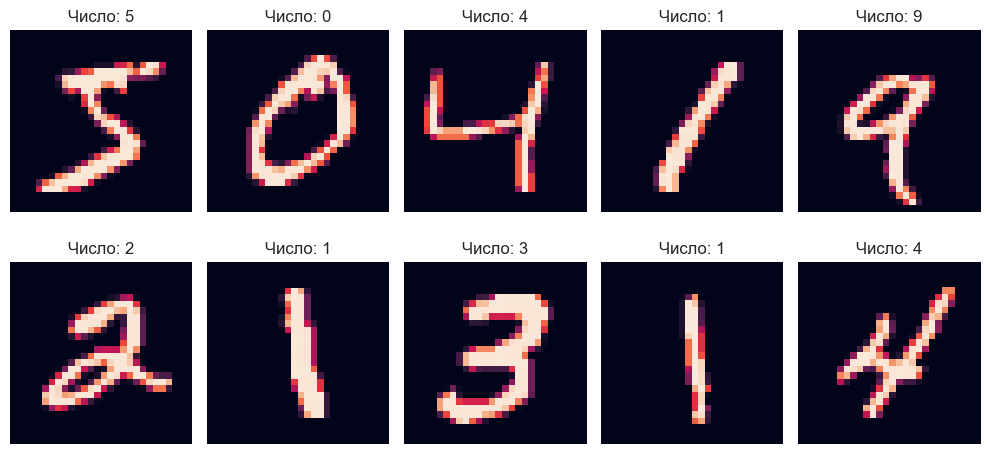

In [23]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"Число: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [24]:
x_train = x_train.reshape(-1, 784).astype("float32") / 255
x_test = x_test.reshape(-1, 784).astype("float32") / 255

In [25]:
def build_and_train(name, layer_sizes):
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(784,)))

    for size in layer_sizes:
        model.add(layers.Dense(size, activation='relu'))

    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

    predictions = model.predict(x_test)
    predicted_classes = np.argmax(predictions, axis=1)

    errors = np.where(predicted_classes != y_test)[0]
    print(f"==== {name} ====")
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Всего ошибок: {len(errors)} из {len(y_test)}")

    plt.figure(figsize=(12, 7))
    for i, err_idx in enumerate(errors[:10]):
        plt.subplot(2, 5, i + 1)

        plt.imshow(x_test[err_idx].reshape(28, 28), cmap='Reds')

        plt.title(f"Реал: {y_test[err_idx]}\nПредск: {predicted_classes[err_idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(y_test, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Предсказано')
    plt.ylabel('Реальность')
    plt.show()
    print(f"Accuracy: {acc:.4f}")
    return acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step
==== Slim ====
Всего ошибок: 331 из 10000


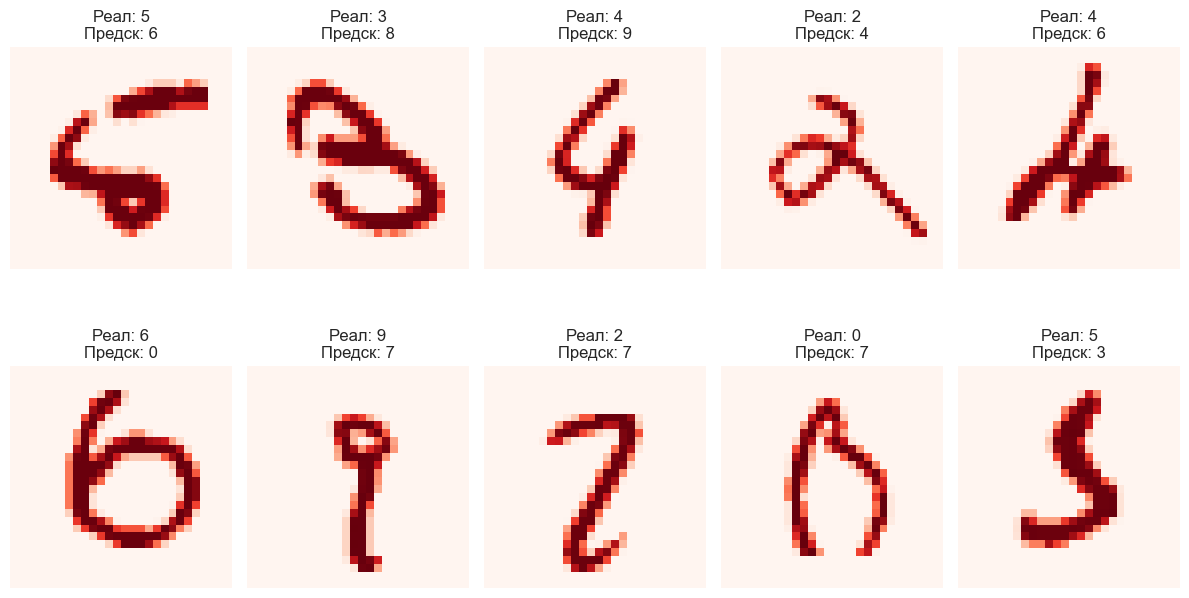

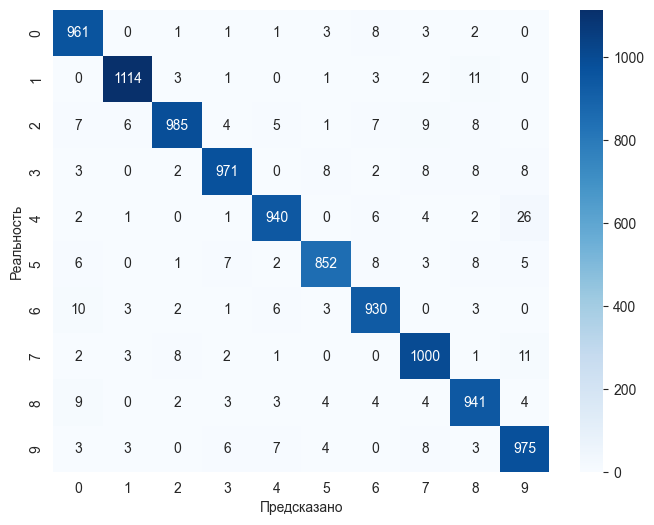

Accuracy: 0.9669
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step
==== Deep ====
Всего ошибок: 279 из 10000


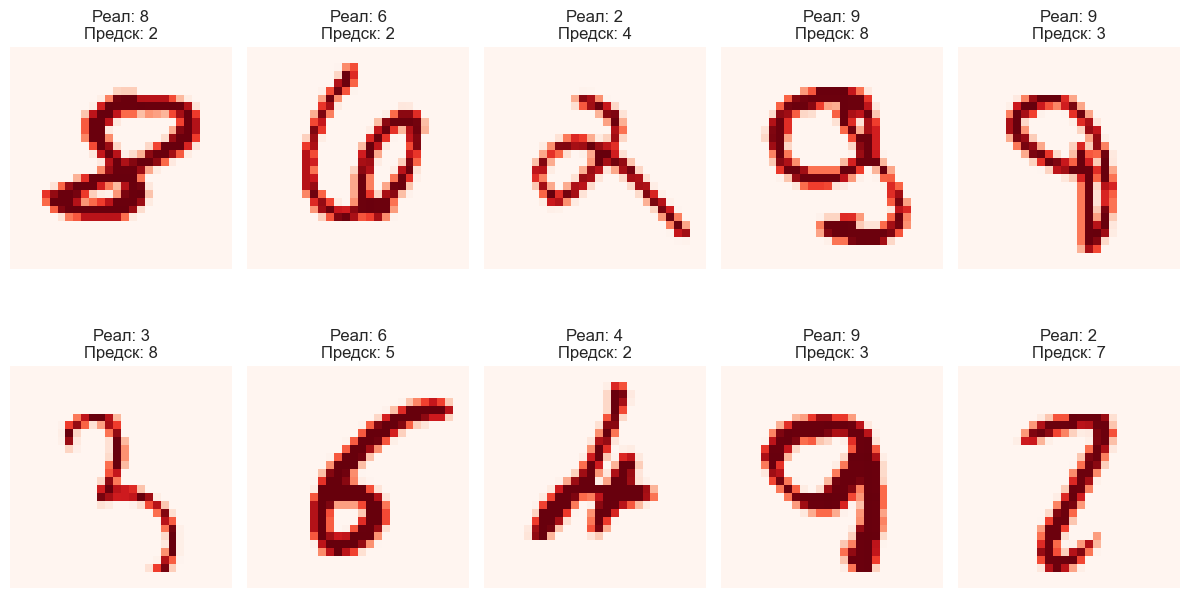

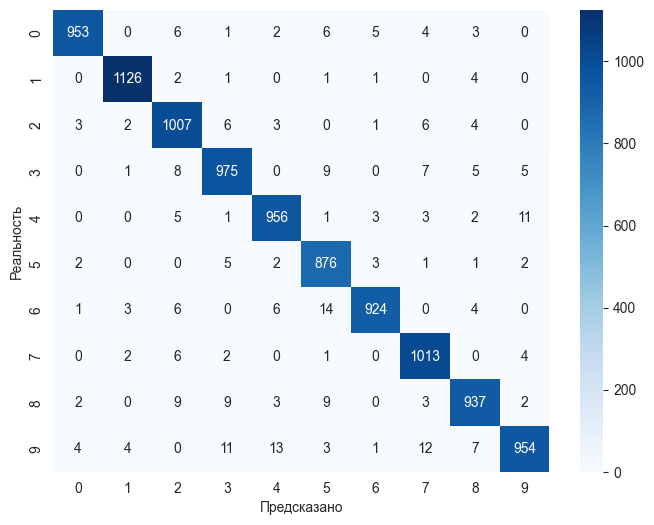

Accuracy: 0.9721
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step
==== Wide ====
Всего ошибок: 194 из 10000


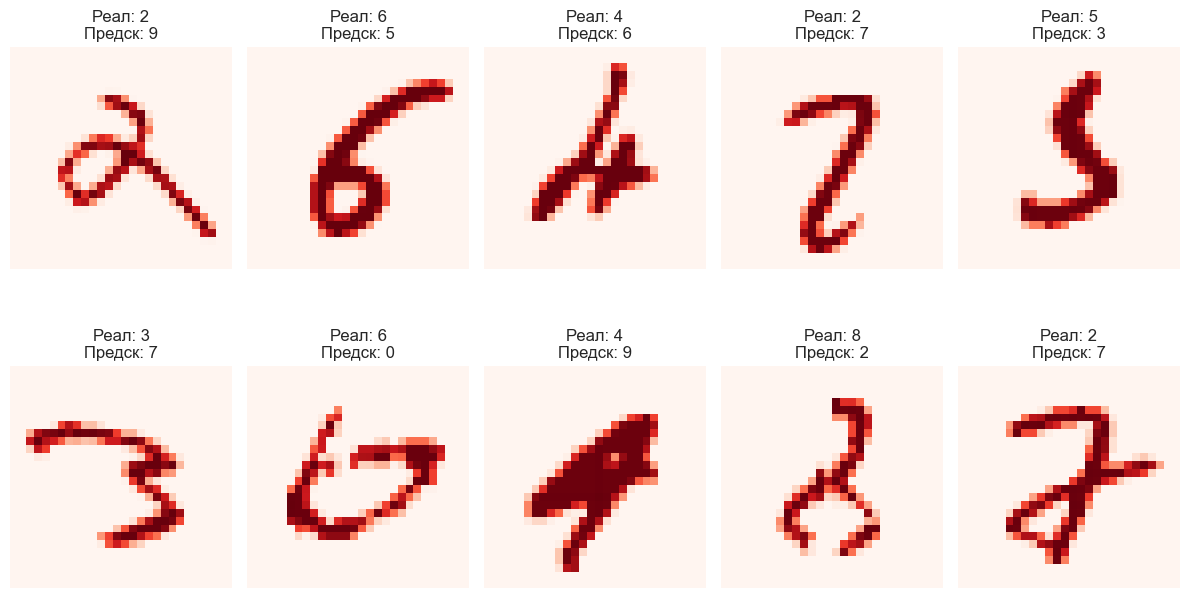

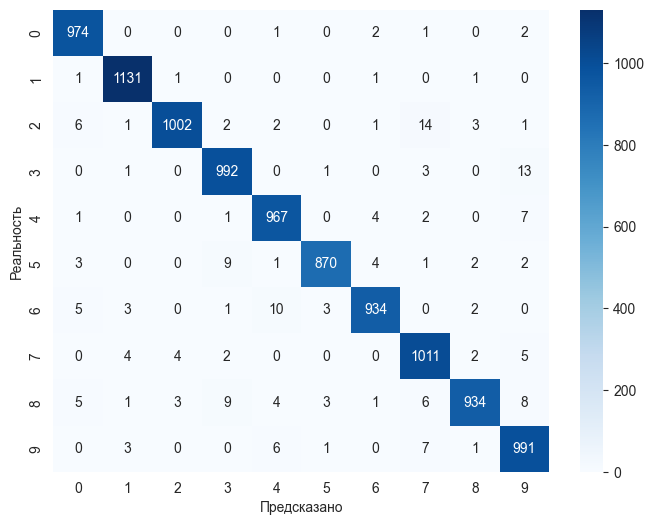

Accuracy: 0.9806


In [26]:
results = {
    "Slim": build_and_train("Slim", [64, 32]),
    "Deep": build_and_train("Deep", [64, 64, 64, 64]),
    "Wide": build_and_train("Wide", [512, 256]),
}